In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.signal import medfilt, wiener

In [3]:
sns.set()

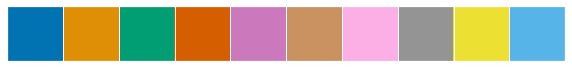

In [4]:
colors = sns.color_palette("colorblind")
# sns.palplot(sns.color_palette("Paired"))
sns.palplot(colors)
sns.set_style("whitegrid")
sns.set_style("ticks",{'axes.grid': True,'grid.color': '.95', 'grid.linestyle': '-'})

In [5]:
def get_metrics(fn):
    ensemble = []
#     metrics = {"training_losses":[],
#                  "validation_losses":[],
#                  "accuracy":[],
#                  "balanced_accuracy":[]}
    with open(fn) as f_pos:
        lines = f_pos.readlines()
        for l in lines:
            if l[0:5] == 'Model':
                ensemble.append({"training_losses":[],
                 "validation_losses":[],
                 "accuracy":[],
                 "balanced_accuracy":[]})
            if l[0] == 'T':
                c = l.split()
                ensemble[-1]["training_losses"].append(float(c[4].strip(',')))
            elif l[0] == 'V':
                c = l.split()
                ensemble[-1]["validation_losses"].append(float(c[4].strip(',')))
                ensemble[-1]["accuracy"].append(float(c[6].strip(',')))
                ensemble[-1]["balanced_accuracy"].append(float(c[8].strip(',')))
    return ensemble

In [6]:
def stats2(ensemble):
    mean = {"training_losses":[],
                 "validation_losses":[],
                 "accuracy":[],
                 "balanced_accuracy":[]}
    max95 = {"training_losses":[],
                 "validation_losses":[],
                 "accuracy":[],
                 "balanced_accuracy":[]}
    min5 = {"training_losses":[],
                 "validation_losses":[],
                 "accuracy":[],
                 "balanced_accuracy":[]}
    for i in range(len(ensemble[0]["training_losses"])):
        for k in ensemble[0].keys():
            mean[k].append(np.mean([e[k][i] for e in ensemble]))
            min5[k].append(np.percentile([e[k][i] for e in ensemble],5))
            max95[k].append(np.percentile([e[k][i] for e in ensemble],95))
    for k in mean.keys():
        mean[k] = np.array(mean[k])
        min5[k] = np.array(min5[k])
        max95[k] = np.array(max95[k])
        
    return mean, min5, max95
    

In [7]:
def create_loss_plot(data, ax, color):
    y_t, y_tmin, y_tmax = data[0]["training_losses"], data[1]["training_losses"], data[2]["training_losses"]
    y_v, y_vmin, y_vmax = data[0]["validation_losses"], data[1]["validation_losses"],data[2]["validation_losses"]
    ax = plt.plot(y_t, color=color, ls=':', label="train")
    ax = plt.plot(y_v, color=color, label="validation")
    ax = plt.fill_between(x, y_tmin, y_tmax, alpha=0.2, linewidth=0, facecolor=color)
    ax = plt.fill_between(x, y_vmin, y_vmax, alpha=0.2, linewidth=0, facecolor=color)
    ax = plt.ylabel("loss", fontsize=9)
    ax = plt.yticks(np.arange(0.2,1.1,0.2), fontsize=9)
    ax = plt.xticks(fontsize=9)
    ax = plt.xlim(-25,525)
    ax = plt.tick_params(length=1)
    

In [8]:
# ylabel hardcoded to balanced accuracy
def create_metric_plot(datas, ax, c, metric="balanced_accuracy"):
    for i in range(len(datas)):
        y, y_min, y_max = datas[i][0][metric], datas[i][1][metric], datas[i][2][metric]
        ax = plt.plot(y, color=c[i])
        ax = plt.fill_between(x, y_min, y_max, alpha=0.2, linewidth=0, facecolor=c[i])
    ax = plt.xlabel("epoch", fontsize=9)
    ax = plt.ylabel("balanced accuracy", fontsize=9)
    ax = plt.ylim(0.40,1.0)
    ax = plt.xlim(-25,525)
    ax = plt.yticks(fontsize=9)
    ax = plt.xticks(fontsize=9)
        

## Read log training files

In [19]:
positives = stats2(get_metrics("../log_model-11-soft-label-age-positives-1000-dropout0-bn-decay-flood-hyperopt-ax-batch256-radam-lc1-20200918"))

In [20]:
negatives = stats2(get_metrics("../log_model-11-soft-label-age-negatives-1000-dropout0-bn-decay-flood-hyperopt-ax-batch256-radam-lc1-20200918"))

In [21]:
random  = stats2(get_metrics("../log_model-11-soft-label-age-random-1000-dropout0-bn-decay-flood-hyperopt-ax-batch256-radam-lc1-20200918"))

In [22]:
ramdomized_positives = stats2(get_metrics("../log_model-11-soft-label-age-randomized_positives-1000-dropout0-bn-decay-flood-hyperopt-ax-batch256-radam-lc1-20200918"))

## Comparação do treinamento do modelo em diferentes conjuntos de SNPs

#### Comparação do treinamento com o conjunto aleatorizado de SNPs associados

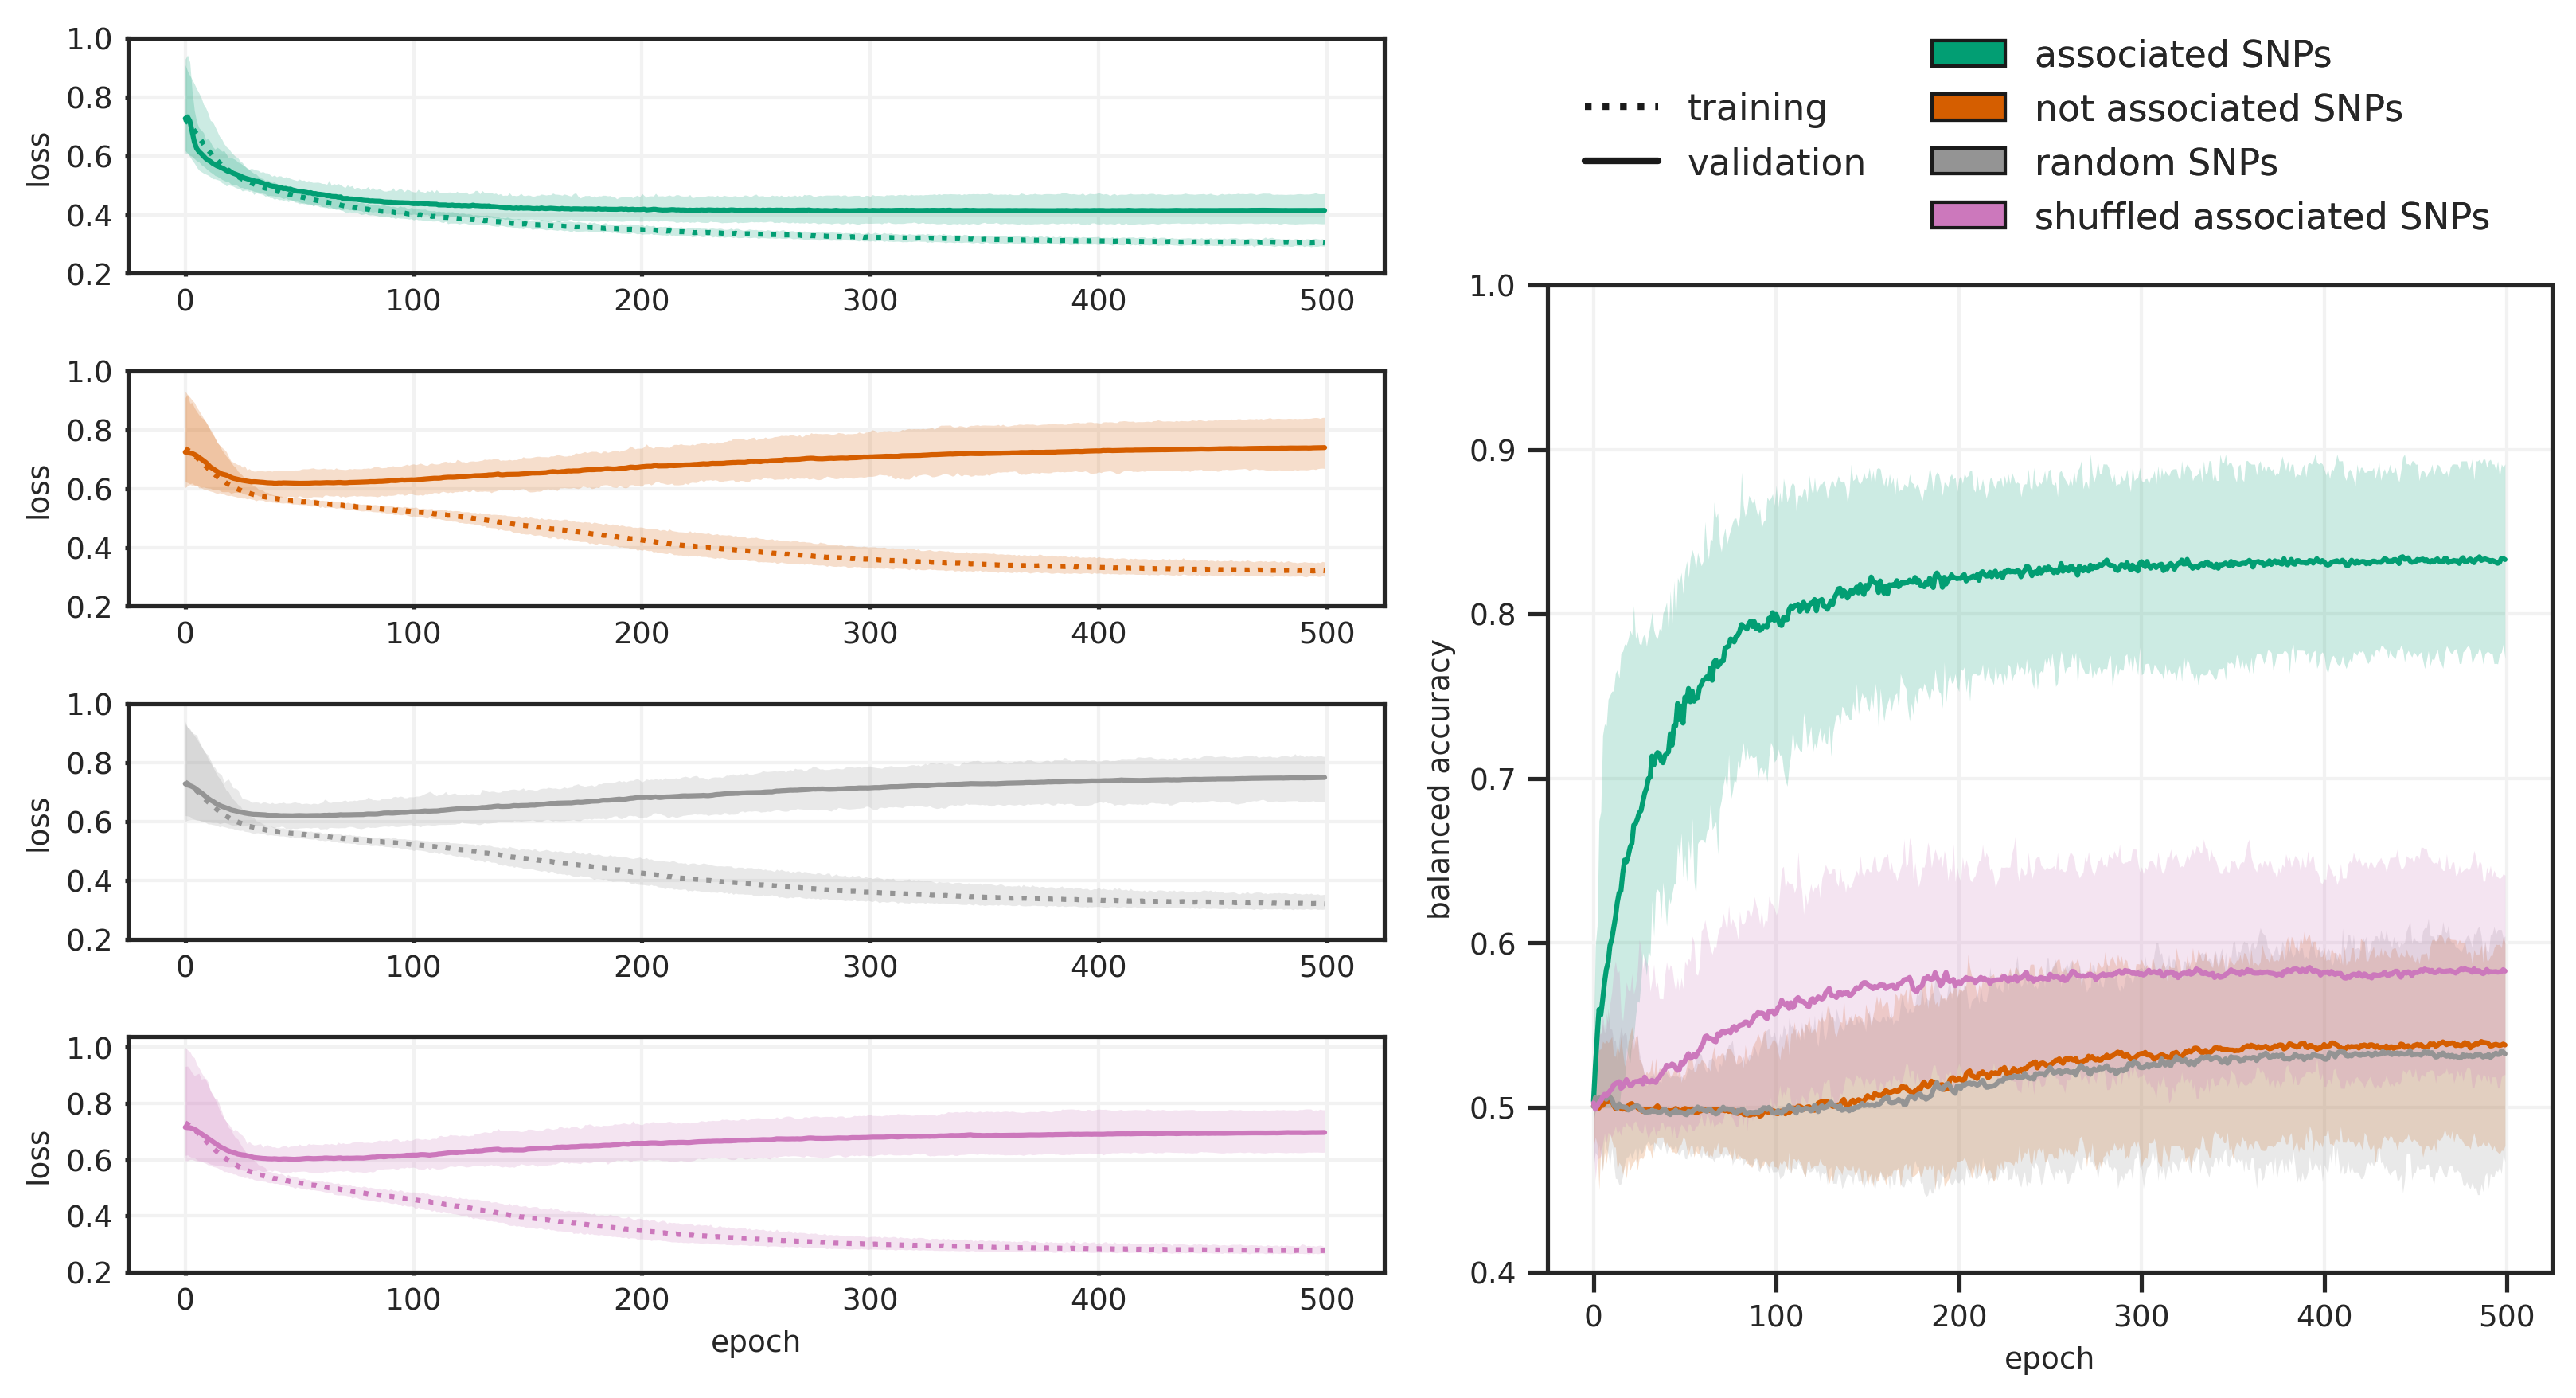

In [23]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# create figure
x = range(len(positives[0]["training_losses"]))
fig = plt.figure(figsize=(12,6), dpi=300)
ax_l1 = plt.subplot(421)
create_loss_plot(positives, ax_l1, colors[2])
ax_l2 = plt.subplot(423)
create_loss_plot(negatives, ax_l2, colors[3])
ax_l3 = plt.subplot(425)
create_loss_plot(random, ax_l3, colors[7])
ax_l4 = plt.subplot(427)
create_loss_plot(ramdomized_positives, ax_l4, colors[4])
ax_l4 = plt.xlabel("epoch", fontsize=9)
ax_r = plt.subplot(122)
create_metric_plot([positives, negatives, random, ramdomized_positives], ax_r,[colors[2], colors[3], colors[7], colors[4]] )
fig = plt.tight_layout()



legend_lines = [Line2D([0], [0], color='k', lw=2, ls=':', label='training'),
                   Line2D([0], [0], color='k', lw=2, label='validation')]
legend_colors = [Patch(facecolor=colors[2], edgecolor='k',label='associated SNPs'),
                 Patch(facecolor=colors[3], edgecolor='k',label='not associated SNPs'),
                 Patch(facecolor=colors[7], edgecolor='k',label='random SNPs'),
                 Patch(facecolor=colors[4], edgecolor='k',label='shuffled associated SNPs')]

box = ax_r.get_position()
ax_r.set_position([box.x0, box.y0,
                 box.width * 0.8, box.height * 0.8])
ax_r.add_artist(plt.legend(handles=legend_lines, loc='center right', frameon=False, bbox_to_anchor=(0.35, 1.15)))
ax_r.add_artist(plt.legend(handles=legend_colors, loc='center left', frameon=False, bbox_to_anchor=(0.35, 1.15)))
## to put legend below bacc plot
# ax_r.set_position([box.x0, box.y0 + box.height * 0.25,
#                  box.width * 0.75, box.height * 0.75])
# ax_r.add_artist(plt.legend(handles=legend_lines, loc='center right', frameon=False, bbox_to_anchor=(0.35, -0.3)))
# ax_r.add_artist(plt.legend(handles=legend_colors, loc='center left', frameon=False, bbox_to_anchor=(0.35, -0.3)))

# plt.savefig("./images/training_plot_radam.svg")